# t-SNE Analysis: In Vivo vs In Vitro Enzyme-Substrate Space

TO DO: Update this read me for variability analysis

This notebook demonstrates the complete pipeline for comparing in vivo and in vitro enzyme datasets using t-SNE visualization.

## Objectives
- **Coverage**: Are in vitro and in vivo entries populating the same biochemical neighborhoods?
- **Gaps**: Which regions have only in vivo (no assays) or only in vitro (no in vivo estimate)?
- **Local comparison**: In regions where both exist, do in vivo values run systematically lower than in vitro?

## Pipeline Overview
1. Get protein embeddings from ESM-2 650M (1280-d, cached per unique sequence)
2. Get substrate embeddings from RDKit ECFP6 (Morgan count fingerprint, radius=3, nBits=2048)
3. Concatenate and scale [protein_embed || substrate_ecfp]
4. PCA reduction to 50–128 dims for denoising & speed
5. t-SNE mapping with color coding by dataset (in vitro vs in vivo)
6. Coverage analysis to identify gaps and overlaps


In [18]:
# automatic module reloading
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add paths & directories for imports
sys.path.append(str(Path("..").resolve()))
# Set up paths
HOME_DIR = os.path.expanduser("~")
CACHE_DIR = os.path.join(HOME_DIR, "cache")
RESULTS_DIR = os.path.join(HOME_DIR, "results")

# import complete pipeline
from scripts.tsne_kcats import run_tsne_pipeline_invivo_invitro

# plotting style
plt.style.use('default')
sns.set_palette("husl")

# Data directory
data_dir = Path("..") / "data"
home_dir = Path.home()
cache_dir = Path.home() / "cache"
print(f"Home: {home_dir}")
print(f"Cache: {cache_dir}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Home: /home/chinasse
Cache: /home/chinasse/cache


## Check Data Overview


In [19]:
# Load datasets
kmax_eta_file = data_dir/'final'/'kcat_app'/'iml1515_homomeric_kmax_pFBA_variability.csv'
kmax_eta_df = pd.read_csv(kmax_eta_file)
kmax_eta_df.head()                         

,sequence,SMILES,kcat_app_max,condition_max,p_total_max,gene,rxn,flux_value,protein_mmol_gdcw,subsystem,eta_mean,eta_stdev,eta_min,eta_max,eta_cv
0,MMITLRKLPLAVAVAAGVMSAQAMAVDFHGYARSGIGWTGSGGEQQ...,O=C[C@H](O)[C@@H](O)[C@H](O)[C@H](O)CO,4332.607908,flux_cond7,0.32,b4036,GLCtex_copy1,10.000000,6.411330e-07,"Transport, Outer Membrane",0.463490,0.283819,0.116364,1.0,0.612351
1,MDFSLTEEQELLLASIRELITTNFPEEYFRTCDQNGTYPREFMRAL...,C/C=C/C(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)...,3857.579892,flux_cond9,0.32,b1695,ACOAD1fr,0.292461,2.105965e-08,Membrane Lipid Metabolism,0.447339,0.265150,0.109564,1.0,0.592726
2,MDFSLTEEQELLLASIRELITTNFPEEYFRTCDQNGTYPREFMRAL...,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,3857.579892,flux_cond9,0.32,b1695,ACOAD1fr,0.292461,2.105965e-08,Membrane Lipid Metabolism,0.447339,0.265150,0.109564,1.0,0.592726
3,MPNITWCDLPEDVSLWPGLPLSLSGDEVMPLDYHAGRSGWLLYGRG...,[NH3+][C@@H](COP(=O)([O-])[O-])C(=O)[O-],1997.321299,flux_cond9,0.32,b4388,PSP_L,1.411713,1.963342e-07,Glycine and Serine Metabolism,0.447339,0.265150,0.109564,1.0,0.592726
4,MLKYRLISAFVLIPVVIAALFLLPPVGFAIVTLVVCMLAAWEWGQL...,CCCCCCC=CCCCCCCCC(=O)OCC(COP(=O)([O-])O)OC(=O)...,646.603533,flux_cond9,0.32,b0175,DASYN161,0.061811,2.655358e-08,Glycerophospholipid Metabolism,0.447339,0.265150,0.109564,1.0,0.592726


In [20]:
from scripts.kcat_utils import group_eta_variability

kmax_eta_grouped_df = group_eta_variability(kmax_eta_file)
kmax_eta_grouped_df.head()

# Create directory and define file path
eta_grouped_file = data_dir / 'processed' / 'kmax' / 'iml1515_homomeric_kmax_pFBA_variability_grouped.csv'
eta_grouped_file.parent.mkdir(parents=True, exist_ok=True)

# Save the CSV
kmax_eta_grouped_df.to_csv(eta_grouped_file, index=False)


High variance: 102 enzymes
Low variance: 94 enzymes
Medium variance: 177 enzymes


## Install Required Dependencies

Note: You need to install the required packages before running the pipeline:


In [21]:
# Uncomment and run if you need to install dependencies
# !pip install fair-esm torch rdkit-pypi scikit-learn matplotlib seaborn pandas numpy

# Check if ESM is available
try:
    import esm
    print("ESM is available")
except ImportError:
    print("ESM not available. Install with: pip install fair-esm")

# Check if RDKit is available  
try:
    from rdkit import Chem
    print("RDKit is available")
except ImportError:
    print("RDKit not available. Install with: pip install rdkit-pypi")


ESM is available
RDKit is available


## Run Complete t-SNE Pipeline

This will execute all steps of the pipeline:
1. Compute protein embeddings (cached)
2. Compute substrate embeddings
3. Combine and scale embeddings
4. Apply PCA reduction
5. Generate t-SNE visualization
6. Analyze coverage patterns


=== Starting t-SNE Variability Pipeline ===
Loading variability data...
Total entries: 373
High variability entries: 102
Low variability entries: 94

=== Step 1: Computing protein embeddings ===
Computing embeddings for 110 unique sequences...
Loading embedding from cache: /home/chinasse/cache/protein_embeddings/variability/c93c8f314eb2a28915971d9ae89a9ac9.pkl
Loading embedding from cache: /home/chinasse/cache/protein_embeddings/variability/d7cfd88177bda29164d71217f3bdd681.pkl
Loading embedding from cache: /home/chinasse/cache/protein_embeddings/variability/b6cb369f06acaecc00322377c74e9f11.pkl
Loading embedding from cache: /home/chinasse/cache/protein_embeddings/variability/2adc85c04e205bb322f6838caacfc474.pkl
Loading embedding from cache: /home/chinasse/cache/protein_embeddings/variability/a75fa3e22c2a164e8d5632867b4e2dd8.pkl
Loading embedding from cache: /home/chinasse/cache/protein_embeddings/variability/5adfc32c620373e38308e89f4358b1d3.pkl
Loading embedding from cache: /home/chinas

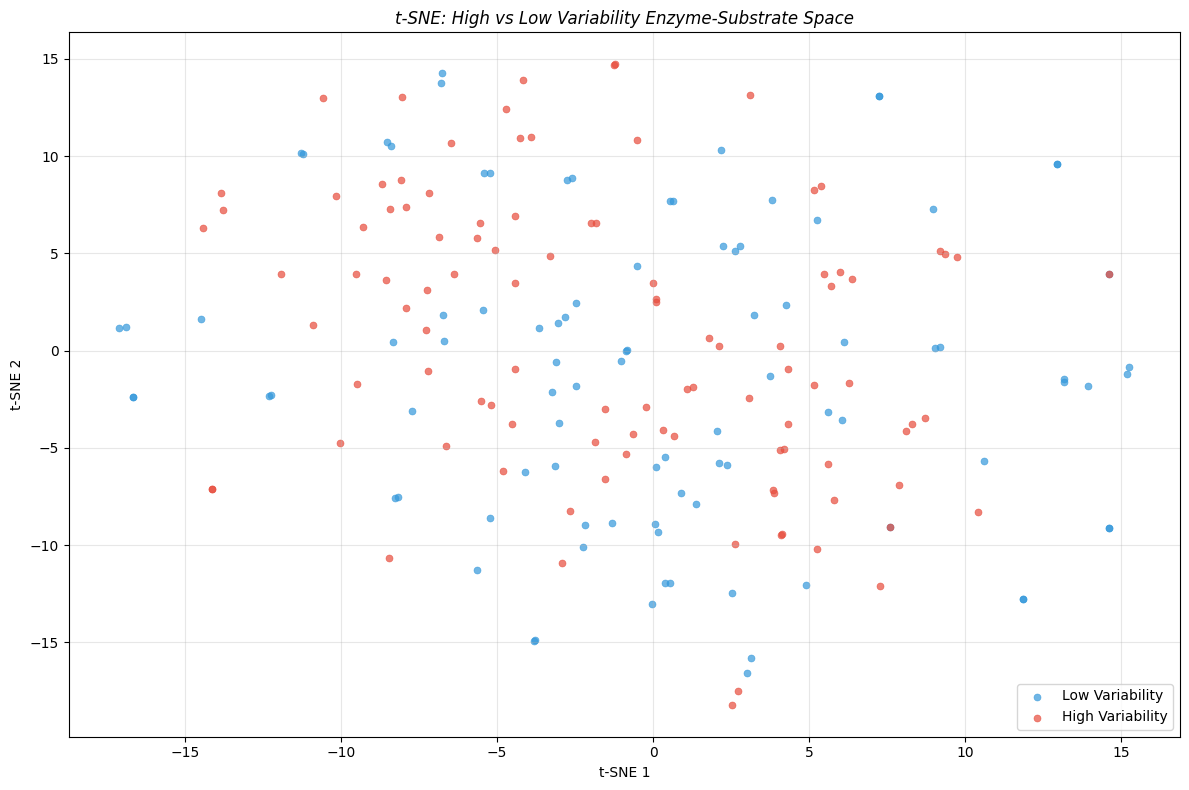

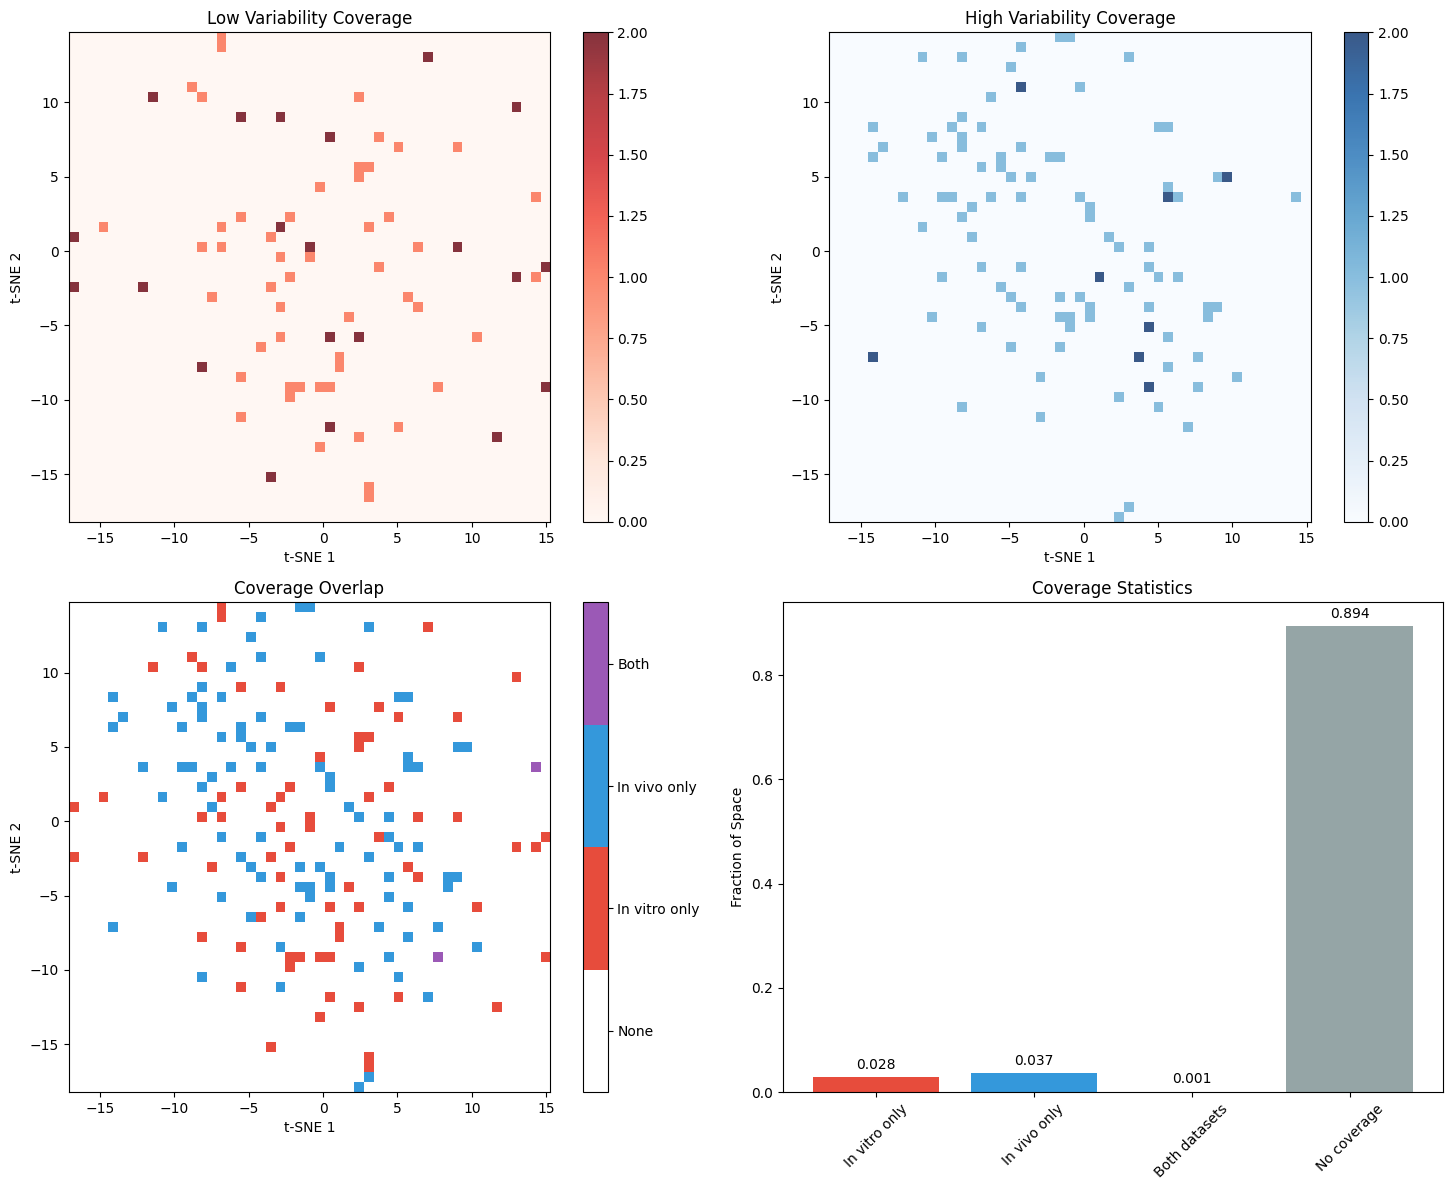

In [23]:
from scripts.tsne_kcats import run_tsne_pipeline_variability

# Run the complete pipeline
results = run_tsne_pipeline_variability(
    eta_grouped_file = eta_grouped_file,
    output_dir = "results/tsne_variability_analysis",
    pca_components = 100,
    cache_dir = str(cache_dir),
    use_substrates=True
)
